# SDSS Datathon 2026  - Predicting Financial Impact of Economic Shocks Using Machine Learning

### Team 36 Members
- Yaxian Meng
- Yuk Ching Kam
- Celine Chen
- Haizhiling Lyu

##  Project Overview

Large-scale economic shocks, such as the COVID-19 pandemic, affect individuals differently depending on their demographic and financial profiles. Understanding financial vulnerability is important for designing targeted support and improving economic resilience.

This project builds a supervised machine learning framework to estimate the **probability distribution** of an individual's financial outcome during a future shock.

Given an individual's demographic and financial characteristics, our model predicts the probability that their financial situation will:

- **Improve**
- **Remain Stable**
- **Worsen**

Rather than predicting a single class label, the model outputs **class probabilities**, providing a more nuanced view of risk and uncertainty.

## 1. Setup: Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_load import load_data
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

from src.config import (
    DATA_PATH, SHEET_NAME, TARGET_COL,
    FEATURES, CATEGORICAL_COLS,
    LABEL_MAP, RANDOM_STATE, TEST_SIZE
)

## 2. Sanity Check: Paths & Environment

In [2]:
print("Working dir:", os.getcwd())
print("DATA_PATH exists:", os.path.exists(DATA_PATH))

Working dir: /Users/lvhaizhiling/UofT/Datathon/datathon-2026
DATA_PATH exists: True


## 3. Data Loading: Read Excel & Inspect

In [3]:
df = load_data()
print(df.shape)
df.head()
print(df.columns.tolist())

(16241, 19)
['Age Group', 'Credit Card Payment', 'COVID Financial Impact', 'Skipped Payments', 'Education Level', 'After-Tax Income', 'Family Type', 'Home Ownership', 'Work Status 2022', 'Number of Earners', 'Province of residence', 'Home Value', 'Bank Deposits', 'TFSA Balance', 'Mortgage Debt', 'Student Loan Debt', 'Credit Card Debt', 'Line of Credit Debt', 'Net Worth']


## 4. Data Cleaning: Select Features + Target

In [4]:
print("FEATURES sample:", FEATURES[:])
print("TARGET_COL:", TARGET_COL)
print("df columns sample:", list(df.columns)[:10])

FEATURES sample: ['Age Group', 'Province of residence', 'Education Level', 'After-Tax Income', 'Home Ownership', 'Mortgage Debt', 'Student Loan Debt', 'Credit Card Debt', 'Line of Credit Debt', 'Bank Deposits', 'TFSA Balance', 'Credit Card Payment']
TARGET_COL: COVID Financial Impact
df columns sample: ['Age Group', 'Credit Card Payment', 'COVID Financial Impact', 'Skipped Payments', 'Education Level', 'After-Tax Income', 'Family Type', 'Home Ownership', 'Work Status 2022', 'Number of Earners']


In [5]:
needed = FEATURES + [TARGET_COL]
df = df[needed].copy()
df = df.dropna(subset=[TARGET_COL])
df[TARGET_COL] = df[TARGET_COL].astype(int)

# ===============================
# Create modeling dataset
# ===============================

X = df[FEATURES].copy()
y = df[TARGET_COL].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

df.head()

X shape: (16241, 12)
y shape: (16241,)


,Age Group,Province of residence,Education Level,After-Tax Income,Home Ownership,Mortgage Debt,Student Loan Debt,Credit Card Debt,Line of Credit Debt,Bank Deposits,TFSA Balance,Credit Card Payment,COVID Financial Impact
0,6,35,4.0,115525,1,0,0,0,0,16000,90000,4.0,3
1,7,47,NaN,121300,1,0,0,0,145000,2900,15500,4.0,3
2,5,48,4.0,19175,1,0,0,0,40000,5000,50000,4.0,3
3,6,35,4.0,147425,2,180000,0,18500,10000,1050,11500,3.0,3
4,4,35,3.0,56750,3,0,0,0,0,0,0,4.0,3


## 5. Exploratory Data Analysis: Target Distribution

RESET LABEL_MAP: {1: 'Improved', 2: 'Worsened', 3: 'Stayed same'}
counts.index BEFORE = [1, 2, 3]
COVID Financial Impact
1    1801
2    4988
3    9452
Name: count, dtype: int64


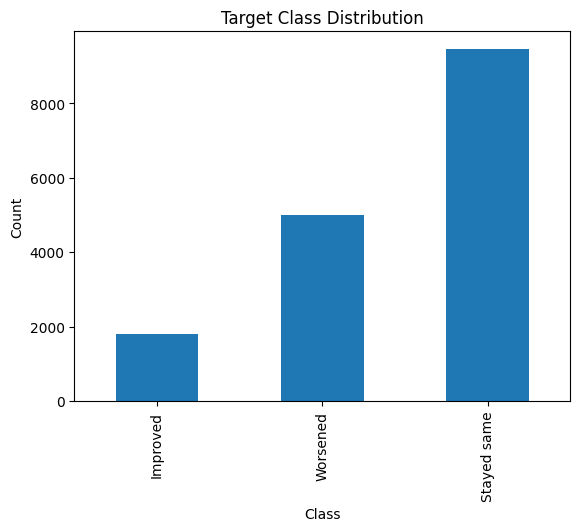

In [6]:
from src.config import LABEL_MAP as CFG_LABEL_MAP

LABEL_MAP = CFG_LABEL_MAP

print("RESET LABEL_MAP:", LABEL_MAP)

y = df[TARGET_COL]
counts = y.value_counts().sort_index()

print("counts.index BEFORE =", list(counts.index))

print(counts)

counts.rename(LABEL_MAP).plot(kind="bar")

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


## 6. Preprocessing: Missing Values & Data Types

In [7]:
df = load_data()

# -----------------------------
# Check missing values AFTER codebook rules
# -----------------------------
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
}).head(20)

,missing_count,missing_%
Family Type,1535,9.45
Credit Card Payment,1115,6.87
Number of Earners,619,3.81
Work Status 2022,598,3.68
Education Level,571,3.52
Bank Deposits,0,0.00
Line of Credit Debt,0,0.00
Credit Card Debt,0,0.00
Student Loan Debt,0,0.00
Mortgage Debt,0,0.00


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (12992, 12) Test size: (3249, 12)


## 7. Model: Train/Test Split & Logistic Regression Pipeline

In [9]:
numeric_cols = [col for col in FEATURES if col not in CATEGORICAL_COLS]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
        ("num", StandardScaler(), numeric_cols),
    ]
)

model = LogisticRegression(
    max_iter=3000,
    solver="lbfgs",
    class_weight="balanced"
)

pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", model)
])

# pipe


In [10]:
#pipe.fit(X_train, y_train)
pipe.fit(X_train, y_train)
print("Model fitted.")

Model fitted.


In [11]:
y_pred = pipe.predict(X_test)

In [12]:
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
macro = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", round(acc, 3))
print("Balanced Accuracy:", round(bacc, 3))
print("Macro F1:", round(macro, 3))

Accuracy: 0.48
Balanced Accuracy: 0.492
Macro F1: 0.436


In [13]:
print(classification_report(
    y_test, y_pred,
    target_names=list(LABEL_MAP.values()),
    digits=3
))

              precision    recall  f1-score   support

    Improved      0.205     0.586     0.304       360
    Worsened      0.463     0.378     0.416       998
 Stayed same      0.689     0.513     0.588      1891

    accuracy                          0.480      3249
   macro avg      0.453     0.492     0.436      3249
weighted avg      0.566     0.480     0.504      3249



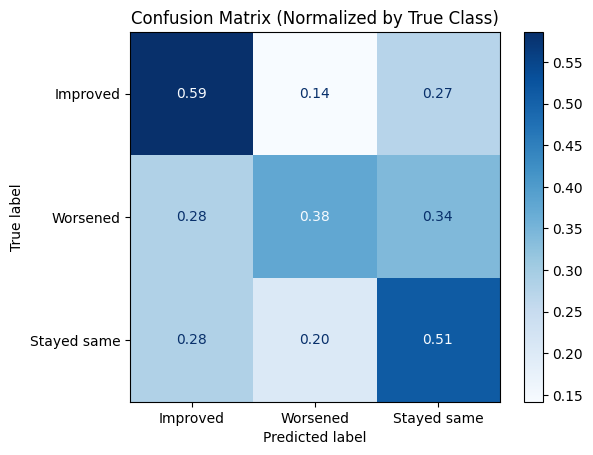

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=list(LABEL_MAP.values()),
    normalize="true",
    cmap="Blues",
    values_format=".2f"
)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.show()

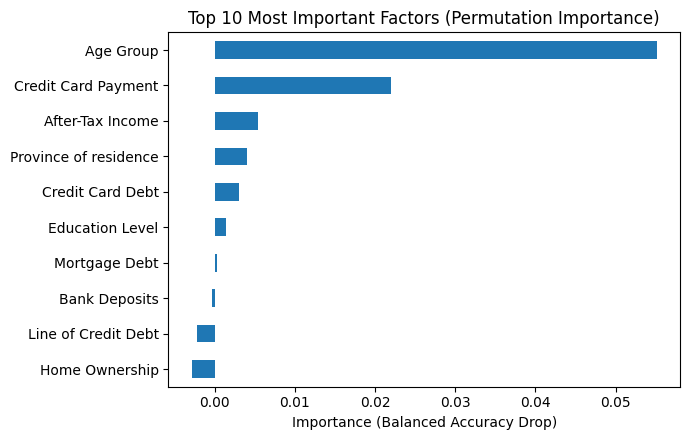

In [15]:
result = permutation_importance(
    pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="balanced_accuracy"
)

imp = pd.Series(result.importances_mean, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
imp.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Most Important Factors (Permutation Importance)")
plt.xlabel("Importance (Balanced Accuracy Drop)")
plt.tight_layout()
plt.show()

## 8. Model Inference Demo (Example Prediction)

In [16]:
# Code Demo
assert hasattr(pipe, "predict_proba"), "pipe is not a fitted model/pipeline"
print("pipe type:", type(pipe))

example_user = {
    "Age Group": 4, #age
    "Province of residence": 35, #province
    "Education Level": 4, #education level
    "After-Tax Income": 600000, #after-tax income
    "Home Ownership": 1, #homeownership
    "Mortgage Debt": 3000, #mortgage debt
    "Student Loan Debt": 1000, #student loan debt
    "Credit Card Debt": 20000, #credit card debt
    "Line of Credit Debt": 5000,   #line of credit debt
    "Bank Deposits": 8000, #bank deposits
    "TFSA Balance": 6000, #TFSA balance
    "Credit Card Payment": 2, 
}

user_df = pd.DataFrame([example_user]).reindex(columns=FEATURES)
proba = pipe.predict_proba(user_df)[0]
final_step_name = list(pipe.named_steps.keys())[-1]
classes = pipe.named_steps[final_step_name].classes_

for cls, p in zip(classes, proba):
    print(LABEL_MAP[int(cls)], ":", round(float(p), 3))

pred = pipe.predict(user_df)[0]
print("Predicted:", LABEL_MAP[int(pred)])

pipe type: <class 'sklearn.pipeline.Pipeline'>
Improved : 0.277
Worsened : 0.466
Stayed same : 0.257
Predicted: Worsened
